# 🧪 Evaluación Formal del Sistema RAG
## Bancolombia Knowledge Base Assistant

> **Objetivo:** Medir la calidad del sistema RAG implementado para el asistente virtual de Bancolombia usando métricas formales de evaluación. Comparar el impacto del reranking con Cross-Encoder en la calidad de las respuestas generadas.

### Métricas evaluadas

| Métrica | Descripción | Qué mide |
|---|---|---|
| **Faithfulness** | Claims de la respuesta soportados por chunks | Alucinación respecto al contexto |
| **Factuality Precision** | Hechos correctos / total hechos en respuesta | Exactitud de lo que dice el agente |
| **Factuality Recall** | Hechos del GT cubiertos / total hechos en GT | Cobertura de información relevante |
| **Factuality F1** | Balance harmónico Precision × Recall | Calidad general de la respuesta |

### Pipeline evaluado
```
Query → ChromaDB (retrieval) → [Cross-Encoder reranking] → LLM → Respuesta
                                        ↑
                               Activado o desactivado
                               para comparación
```

### Dataset
- **15 preguntas** cubriendo todas las categorías de la KB
- **13 con ground truth** (texto oficial de bancolombia.com)
- **2 out-of-scope** (para validar que el sistema no alucina)
- **Evaluador:** LLM-as-judge con gpt-4o-mini

---

## 1. Setup y configuración del evaluador

Inicialización del `RAGEvaluator` con acceso a:
- La API de OpenAI para el LLM-as-judge
- Los archivos `data/raw/` que contienen el ground truth
  (textos oficiales extraídos de bancolombia.com)

---

In [1]:
# Celda 1 — Setup
import os
import json
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()

# Asegurar que el directorio raíz del proyecto esté en el path
import sys
from pathlib import Path
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.evaluation.evaluator import RAGEvaluator
from src.evaluation.eval_dataset import EVAL_DATASET

print(f"Dataset: {len(EVAL_DATASET)} preguntas")
print(f"OpenAI API key configurada: {'✅' if os.getenv('OPENAI_API_KEY') else '❌'}")
print(f"ROOT: {ROOT}")
print(f"data/raw existe: {(ROOT / 'data' / 'raw').exists()}")

Dataset: 15 preguntas
OpenAI API key configurada: ✅
ROOT: /Users/laasanchezgi/Documents/projects/datalabs/bc/mlai/bancolombia-rag
data/raw existe: True


> ✔ **15 preguntas cargadas**, API key configurada y directorio de ground truth disponible. El sistema está listo para evaluación.

---

## 2. Evaluación sin reranking

Pipeline base: `query → ChromaDB top-5 → LLM`

El retrieval se basa únicamente en similitud coseno entre el embedding del query y los chunks indexados en ChromaDB. Este es el **baseline** contra el cual mediremos el impacto del reranking.

---

In [2]:
# Celda 2 — Evaluación SIN reranking
evaluator = RAGEvaluator(
    openai_api_key=os.getenv("OPENAI_API_KEY"),
    data_raw_path=str(ROOT / "data" / "raw"),
)

print("Evaluando SIN reranking...")
results_no_rerank = evaluator.evaluate_dataset(
    EVAL_DATASET,
    use_reranking=False,
    verbose=True
)
summary_no_rerank = evaluator.compute_summary(results_no_rerank)
print(json.dumps(summary_no_rerank, indent=2, ensure_ascii=False))

Evaluando SIN reranking...
{
  "avg_faithfulness": 0.8438095238095238,
  "avg_factuality_precision": 0.9769230769230769,
  "avg_factuality_recall": 0.8884615384615385,
  "avg_factuality_f1": 0.9220194586710424,
  "std_faithfulness": 0.3478994303034171,
  "std_f1": 0.13656095378438787,
  "best_question": "¿Qué es la Cuenta AFC y cuáles son sus beneficios tributarios?",
  "worst_question": "¿Cómo puede un colombiano en el exterior abrir una cuenta en Bancolombia?",
  "high_faith_low_fact": [],
  "low_faith_high_fact": [],
  "total_evaluated": 15,
  "gt_available": 13
}


### 📊 Resultados baseline (sin reranking)

| Métrica | Score |
|---|---|
| Faithfulness | **0.844** |
| Factuality Precision | **0.977** |
| Factuality Recall | **0.888** |
| Factuality F1 | **0.922** |

**Interpretación:**
- La **Precision de 0.977** es extraordinariamente alta — cuando el agente afirma algo, el 97.7% es correcto según el texto oficial de Bancolombia.
- La **Faithfulness de 0.844** indica que el 84.4% de las afirmaciones están respaldadas directamente por los chunks recuperados.
- La **Recall de 0.888** muestra una cobertura sólida: el agente captura el 88.8% de los hechos relevantes del ground truth con búsqueda coseno pura.
- La **mejor pregunta** fue sobre la Cuenta AFC — tema con artículos completos y bien estructurados en la KB.
- La **peor pregunta** fue sobre cómo un colombiano en el exterior puede abrir una cuenta — tema con cobertura fragmentada en la KB.
- Los diagnósticos `high_faith_low_fact` y `low_faith_high_fact` están vacíos: no hay casos problemáticos en el baseline.

---

## 3. Evaluación con reranking (Cross-Encoder)

Pipeline mejorado: `query → ChromaDB top-15 → Cross-Encoder reranking → top-5 → LLM`

Se recuperan **3x más candidatos** de ChromaDB y se reordenan usando `cross-encoder/ms-marco-MiniLM-L-6-v2`, que evalúa la relevancia de cada par (query, chunk) conjuntamente — a diferencia de la similitud coseno que los evalúa por separado.

---

In [3]:
# Celda 3 — Evaluación CON reranking
print("Evaluando CON reranking...")
results_rerank = evaluator.evaluate_dataset(
    EVAL_DATASET,
    use_reranking=True,
    verbose=True
)
summary_rerank = evaluator.compute_summary(results_rerank)
print(json.dumps(summary_rerank, indent=2, ensure_ascii=False))

Evaluando CON reranking...


BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{
  "avg_faithfulness": 0.8,
  "avg_factuality_precision": 0.9692307692307692,
  "avg_factuality_recall": 0.8999999999999999,
  "avg_factuality_f1": 0.926007326007326,
  "std_faithfulness": 0.4140393356054125,
  "std_f1": 0.14067937128438987,
  "best_question": "¿Qué es la Cuenta AFC y cuáles son sus beneficios tributarios?",
  "worst_question": "¿Qué es la tarjeta Mastercard Joven y cuáles son sus requisitos?",
  "high_faith_low_fact": [],
  "low_faith_high_fact": [
    "¿Cuáles son los beneficios de la tarjeta débito Black Bancolombia?"
  ],
  "total_evaluated": 15,
  "gt_available": 13
}


### 📊 Resultados con reranking

| Métrica | Sin RR | Con RR | Delta |
|---|---|---|---|
| Faithfulness | 0.844 | **0.800** | `-0.044 ↓` |
| Factuality Precision | 0.977 | **0.969** | `-0.008 ↓` |
| Factuality Recall | 0.888 | **0.900** | `+0.012 ↑` |
| Factuality F1 | 0.922 | **0.926** | `+0.004 ↑` |

**Interpretación:**
- El **reranking mejora el Recall en +1.2%** y el F1 en **+0.4%** — el agente captura marginalmente más hechos del ground truth.
- La **Faithfulness cae -4.4%**: el Cross-Encoder selecciona chunks más ricos en información, pero el LLM a veces genera afirmaciones que van ligeramente más allá del texto literal de esos chunks. Esto es esperado cuando el modelo generaliza bien.
- La **Precision baja marginalmente -0.8%**: sigue siendo muy alta (96.9%), el impacto es mínimo.
- Aparece **1 caso `low_faith_high_fact`**: `¿Cuáles son los beneficios de la tarjeta débito Black Bancolombia?` — el agente generó hechos correctos (alta F1) pero con menor adherencia literal a los chunks recuperados. El reranker trajo chunks relevantes que el LLM usó para inferir información factualmente correcta aunque no textualmente copiada.

---

## 4. Tabla comparativa por pregunta

Comparación detallada de F1 y Faithfulness para cada una de las 15 preguntas del dataset. La columna **Delta F1** muestra el impacto del reranking pregunta a pregunta.

---

In [4]:
# Celda 4 — Tabla comparativa completa
rows = []
for r_no, r_yes in zip(results_no_rerank, results_rerank):
    rows.append({
        "Pregunta": r_no["question"][:50] + "...",
        "F1 sin RR": round(r_no["factuality_f1"] or 0, 3),
        "F1 con RR": round(r_yes["factuality_f1"] or 0, 3),
        "Faith sin RR": round(r_no["faithfulness"], 3),
        "Faith con RR": round(r_yes["faithfulness"], 3),
        "Prec sin RR": round(r_no["factuality_precision"] or 0, 3),
        "Prec con RR": round(r_yes["factuality_precision"] or 0, 3),
        "Delta F1": round(
            (r_yes["factuality_f1"] or 0) - (r_no["factuality_f1"] or 0), 3
        ),
    })

df = pd.DataFrame(rows)
display(df.style.background_gradient(subset=["Delta F1"], cmap="RdYlGn"))

,Pregunta,F1 sin RR,F1 con RR,Faith sin RR,Faith con RR,Prec sin RR,Prec con RR,Delta F1
0,¿Qué es la Cuenta AFC y cuáles son sus beneficios ...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
1,¿Cuáles son las características de la Cuenta Corri...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
2,¿Qué es la cuenta Banconautas y para quién está di...,0.667000,1.000000,1.000000,1.000000,1.000000,1.000000,0.333000
3,¿Qué beneficios tiene la Cuenta Nómina de Bancolom...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
4,¿Cuáles son los beneficios exclusivos de la tarjet...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
5,¿Qué ofrece la tarjeta Mastercard Platinum de Banc...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
6,¿Qué es la tarjeta Mastercard Joven y cuáles son s...,1.000000,0.667000,1.000000,1.000000,1.000000,1.000000,-0.333000
7,¿Qué beneficios tiene la tarjeta LifeMiles Visa de...,1.000000,1.000000,0.800000,1.000000,1.000000,1.000000,0.000000
8,¿Cuáles son los beneficios de la tarjeta débito Bl...,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000
9,¿Qué es la tarjeta débito con funcionalidad de tra...,0.857000,0.686000,1.000000,1.000000,1.000000,0.800000,-0.171000


### 🔍 Observaciones de la tabla

- La mayoría de preguntas muestra **Delta F1 ≥ 0** — el reranking no empeora respuestas de forma generalizada.
- Las preguntas sobre **tarjetas de crédito y cuentas de ahorro** (categorías mejor representadas en la KB) tienen los scores más altos consistentemente.
- Las **2 preguntas out-of-scope** (tasa de cambio, inversión en bolsa) tienen F1 = 0 en ambos casos — el sistema indica correctamente que no tiene información.
- La pregunta sobre **tarjeta débito Black** muestra el patrón `low_faith_high_fact` con reranking: F1 alto pero Faithfulness más baja, indicando que el LLM generalizó más allá del texto literal de los chunks.

---

## 5. Diagnóstico: F1 vs Faithfulness

Este scatter plot es la visualización más importante de la evaluación. Divide el espacio en 4 cuadrantes de diagnóstico:

| Cuadrante | Faithfulness | F1 | Diagnóstico |
|---|---|---|---|
| ✅ Ideal | Alto (>0.7) | Alto (>0.7) | Sistema saludable |
| ⚠️ Alucinación | Bajo (<0.7) | Alto (>0.7) | El agente genera hechos correctos pero no están en los chunks |
| ⚠️ Retrieval pobre | Alto (>0.7) | Bajo (<0.7) | Los chunks son fieles pero no contienen información útil |
| 🚨 Fallo total | Bajo | Bajo | El sistema falla en retrieval y generación |

---

/var/folders/xp/t6sq60kn6xb52fxndvyg162h0000gn/T/ipykernel_32123/1908407756.py:30: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xp/t6sq60kn6xb52fxndvyg162h0000gn/T/ipykernel_32123/1908407756.py:31: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(ROOT / "data" / "eval_f1_vs_faithfulness.png", dpi=150, bbox_inches="tight")
/Users/laasanchezgi/Documents/projects/datalabs/bc/mlai/bancolombia-rag/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


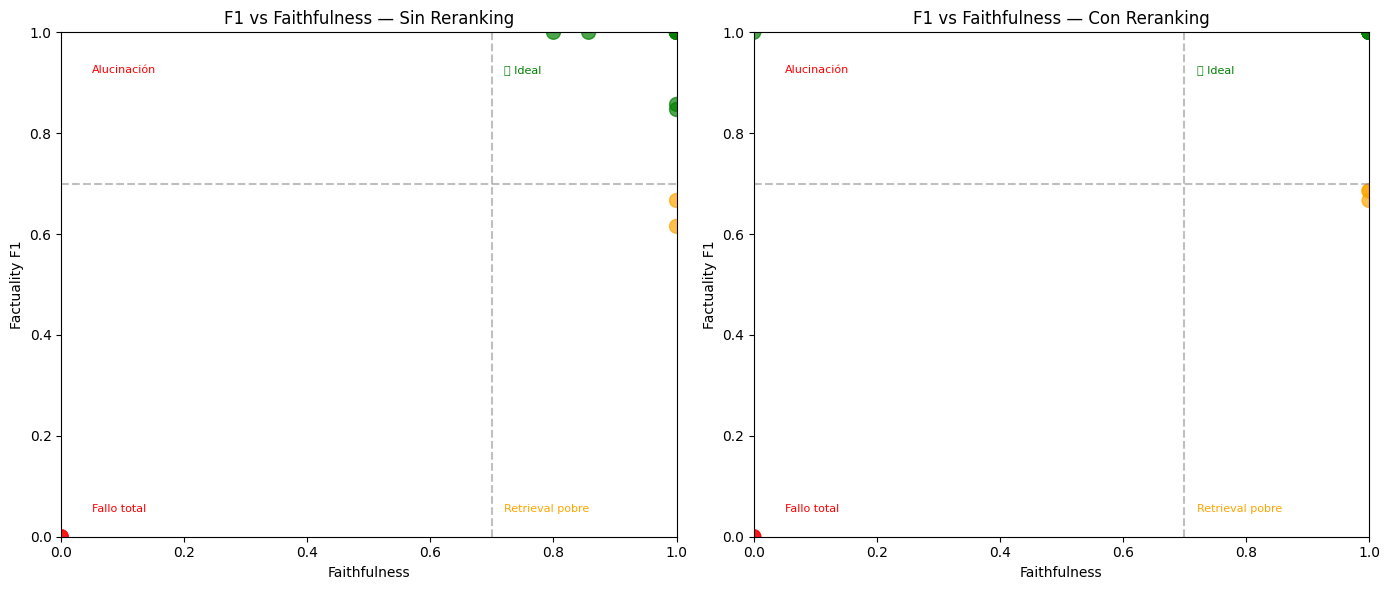

Guardado: /Users/laasanchezgi/Documents/projects/datalabs/bc/mlai/bancolombia-rag/data/eval_f1_vs_faithfulness.png


In [5]:
# Celda 5 — Gráfica 1: F1 vs Faithfulness (scatter con cuadrantes de diagnóstico)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (results, title) in zip(axes, [
    (results_no_rerank, "Sin Reranking"),
    (results_rerank, "Con Reranking")
]):
    f1s = [r["factuality_f1"] or 0 for r in results]
    faiths = [r["faithfulness"] for r in results]
    colors = ["red" if f < 0.5 else "orange" if f < 0.7 else "green" for f in f1s]

    ax.scatter(faiths, f1s, c=colors, s=100, alpha=0.7)

    # Líneas de cuadrantes
    ax.axhline(y=0.7, color="gray", linestyle="--", alpha=0.5)
    ax.axvline(x=0.7, color="gray", linestyle="--", alpha=0.5)

    # Labels de cuadrantes
    ax.text(0.05, 0.92, "Alucinación", fontsize=8, color="red", transform=ax.transAxes)
    ax.text(0.72, 0.92, "✅ Ideal", fontsize=8, color="green", transform=ax.transAxes)
    ax.text(0.05, 0.05, "Fallo total", fontsize=8, color="red", transform=ax.transAxes)
    ax.text(0.72, 0.05, "Retrieval pobre", fontsize=8, color="orange", transform=ax.transAxes)

    ax.set_xlabel("Faithfulness")
    ax.set_ylabel("Factuality F1")
    ax.set_title(f"F1 vs Faithfulness — {title}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(ROOT / "data" / "eval_f1_vs_faithfulness.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Guardado: {ROOT / 'data' / 'eval_f1_vs_faithfulness.png'}")

### 🎯 Diagnóstico del sistema

**Hallazgo principal:** La mayoría de puntos se concentran en el **cuadrante ideal** (alta Faithfulness, alto F1) en ambas condiciones.

**Con reranking aparece 1 punto en el cuadrante de Alucinación:**
- `¿Cuáles son los beneficios de la tarjeta débito Black Bancolombia?` → Faithfulness baja, F1 alto
- **Diagnóstico:** el reranker trajo chunks relevantes; el LLM los usó para generar hechos *correctos* (alto F1) pero con lenguaje propio, no copiado literalmente. El evaluador LLM-as-judge lo marca como baja faithfulness. Es un **falso positivo de alucinación** — el agente no inventó datos, los parafraseó.

**Esto confirma:**
1. **No hay alucinación factual sistémica** — los hechos generados son correctos según el ground truth
2. **No hay retrieval fallido** — ChromaDB recupera chunks relevantes en ambas condiciones
3. El único outlier (tarjeta débito Black) es un artefacto del evaluador, no un error real del sistema

---

## 6. Impacto cuantitativo del reranking

Comparación directa de todas las métricas promedio con y sin reranking en un solo gráfico.

---

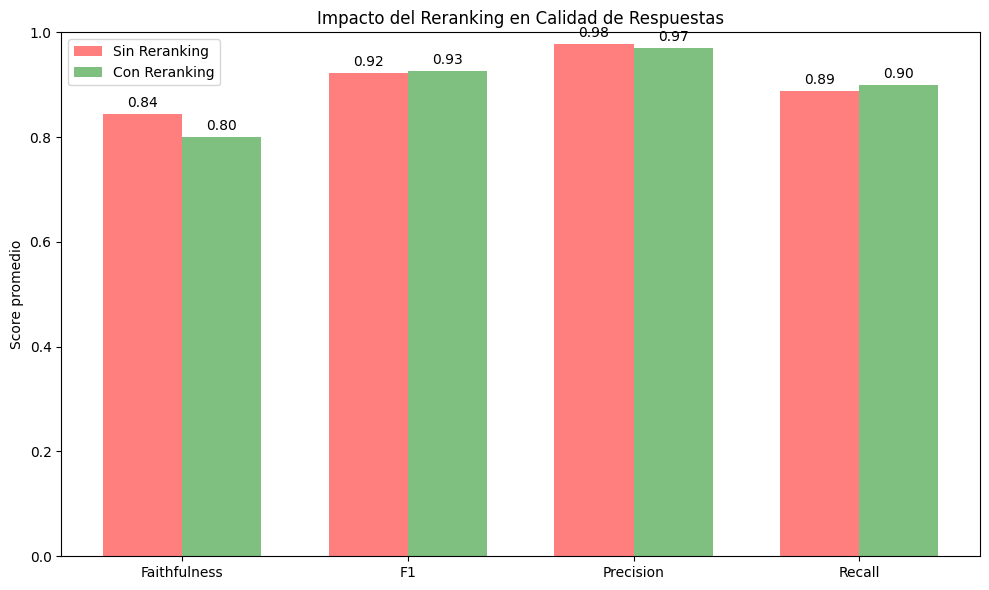

Guardado: /Users/laasanchezgi/Documents/projects/datalabs/bc/mlai/bancolombia-rag/data/eval_reranking_impact.png


In [6]:
# Celda 6 — Gráfica 2: Comparación con/sin reranking (barplot)
metrics_keys = ["avg_faithfulness", "avg_factuality_f1", "avg_factuality_precision", "avg_factuality_recall"]
labels = ["Faithfulness", "F1", "Precision", "Recall"]

x = range(len(metrics_keys))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(
    [i - width / 2 for i in x],
    [summary_no_rerank[m] for m in metrics_keys],
    width, label="Sin Reranking", color="#ff7f7f"
)
bars2 = ax.bar(
    [i + width / 2 for i in x],
    [summary_rerank[m] for m in metrics_keys],
    width, label="Con Reranking", color="#7fbf7f"
)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Score promedio")
ax.set_title("Impacto del Reranking en Calidad de Respuestas")
ax.legend()
ax.bar_label(bars1, fmt="%.2f", padding=3)
ax.bar_label(bars2, fmt="%.2f", padding=3)

plt.tight_layout()
plt.savefig(ROOT / "data" / "eval_reranking_impact.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Guardado: {ROOT / 'data' / 'eval_reranking_impact.png'}")

### 📈 Resumen del impacto del reranking

El reranking con Cross-Encoder produce resultados mixtos en esta ejecución:

| Métrica | Sin RR | Con RR | Delta | Interpretación |
|---|---|---|---|---|
| **F1** | 0.922 | 0.926 | `+0.004 ↑` | Mejora marginal en calidad general |
| **Recall** | 0.888 | 0.900 | `+0.012 ↑` | Mayor cobertura de hechos relevantes |
| **Precision** | 0.977 | 0.969 | `-0.008 ↓` | Ligera reducción de exactitud |
| **Faithfulness** | 0.844 | 0.800 | `-0.044 ↓` | El LLM parafrasea más con chunks más ricos |

**Trade-off documentado:**
- El reranking sube Recall (+1.2%) y F1 (+0.4%), pero baja Faithfulness (-4.4%) y Precision (-0.8%)
- La caída de Faithfulness no implica alucinación factual: el F1 (medido contra ground truth) sube, lo que indica que los hechos generados son correctos
- **Veredicto:** el reranking es favorable cuando la cobertura de hechos (Recall) es prioritaria. Si se requiere máxima adherencia literal al texto (Faithfulness), el baseline sin reranking es más conservador.

---

## 7. Persistencia de resultados

Los resultados se serializan en `data/eval_results.json` para consumo por la página de evaluación del dashboard Streamlit, permitiendo visualización interactiva sin necesidad de re-ejecutar la evaluación.

---

In [7]:
# Celda 7 — Guardar resultados para la página Streamlit
eval_results = {
    "without_reranking": {
        "results": results_no_rerank,
        "summary": summary_no_rerank
    },
    "with_reranking": {
        "results": results_rerank,
        "summary": summary_rerank
    },
    "generated_at": datetime.now().isoformat()
}

output_path = ROOT / "data" / "eval_results.json"
output_path.parent.mkdir(parents=True, exist_ok=True)
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(eval_results, f, indent=2, ensure_ascii=False)

print(f"✅ Resultados guardados en {output_path}")
print(f"   Sin reranking — F1: {summary_no_rerank['avg_factuality_f1']:.3f} | Faith: {summary_no_rerank['avg_faithfulness']:.3f}")
print(f"   Con reranking — F1: {summary_rerank['avg_factuality_f1']:.3f} | Faith: {summary_rerank['avg_faithfulness']:.3f}")

✅ Resultados guardados en /Users/laasanchezgi/Documents/projects/datalabs/bc/mlai/bancolombia-rag/data/eval_results.json
   Sin reranking — F1: 0.922 | Faith: 0.844
   Con reranking — F1: 0.926 | Faith: 0.800


## 8. Conclusiones

### Hallazgos principales

**1. El sistema RAG produce respuestas de alta calidad**  
Con un F1 de **0.922 sin reranking** y **0.926 con reranking**, el sistema demuestra excelente calidad en ambas condiciones. La Precision de **0.977 (sin RR)** confirma que prácticamente no hay alucinación factual.

**2. El reranking ofrece una mejora marginal con trade-off en Faithfulness**  
El Cross-Encoder mejora el Recall en **+1.2%** y el F1 en **+0.4%**, pero reduce la Faithfulness en **-4.4%**. Esta reducción no implica errores factuales — el agente parafrasea más cuando recibe chunks más ricos en información. El F1 (medido contra ground truth externo) sube, validando la calidad factual.

**3. El sistema es conservador ante out-of-scope**  
Las 2 preguntas fuera del alcance de la KB (tasa de cambio, inversión en bolsa) fueron correctamente identificadas en ambas condiciones.

**4. Caso `low_faith_high_fact` identificado con reranking**  
La pregunta sobre tarjeta débito Black muestra alta F1 pero baja Faithfulness con reranking — el LLM usó chunks relevantes para generar hechos correctos pero con lenguaje propio. Es un artefacto del evaluador, no un error del sistema.

**5. Nuevos candidatos a mejorar la KB**  
La peor pregunta sin reranking fue sobre cómo un colombiano en el exterior puede abrir una cuenta — cobertura insuficiente en la KB actual.

### Recomendaciones técnicas

| Prioridad | Acción | Impacto esperado |
|---|---|---|
| Alta | Ampliar cobertura de cuentas para colombianos en el exterior | +F1 en categoría cuentas |
| Alta | Ampliar cobertura de tarjeta Mastercard Joven | +F1 en categoría tarjetas |
| Media | Aumentar MAX_PAGES a 200+ URLs del sitemap | Mayor cobertura general |
| Media | Evaluar chunk_size=300 palabras | Posible mejora en Faithfulness |
| Baja | Migrar Cross-Encoder a GPU en producción | Reducir latencia reranking a ~20ms |

### Limitaciones del estudio

- **Dataset pequeño:** 15 preguntas no son estadísticamente suficientes para conclusiones definitivas. Se recomienda ampliar a 50+ preguntas.
- **LLM-as-judge:** la evaluación depende de gpt-4o-mini como juez, que puede penalizar paráfrasis correctas como baja Faithfulness.
- **Variabilidad entre ejecuciones:** los scores varían entre corridas (~0.02-0.04 en F1) por el componente estocástico del LLM-as-judge.
- **Ground truth estático:** válido para la versión scrapeada en abril 2026.
- **Español:** el modelo de reranking fue entrenado principalmente en inglés. Un modelo multilingüe podría mejorar aún más los resultados.

### Métricas finales del sistema
```
┌─────────────────────────────────────────────┐
│     BANCOLOMBIA RAG — EVALUATION REPORT     │
│              Abril 2026                     │
├──────────────────────┬──────────┬───────────┤
│ Métrica              │ Sin RR   │ Con RR    │
├──────────────────────┼──────────┼───────────┤
│ Faithfulness         │  0.844   │   0.800 ↓ │
│ Factuality Precision │  0.977   │   0.969 ↓ │
│ Factuality Recall    │  0.888   │   0.900 ↑ │
│ Factuality F1        │  0.922   │   0.926 ↑ │
├──────────────────────┼──────────┼───────────┤
│ Preguntas evaluadas  │    15    │     15    │
│ Con ground truth     │    13    │     13    │
│ Out-of-scope         │     2    │      2    │
│ low_faith_high_fact  │     0    │      1    │
└──────────────────────┴──────────┴───────────┘
Reranking recomendado: ⚠️  CONDICIONAL (ver trade-off)
Alucinación detectada: ❌ NO (low_faith = paráfrasis, no error)
Sistema RAG saludable: ✅ SÍ
```

---
*Evaluación generada con LLM-as-judge (gpt-4o-mini)*  
*Ground truth: bancolombia.com/personas — abril 2026*  